# Climate Change in Two Cities: 1940 to Today
### Karachi, Pakistan and London, United Kingdom, from 86 years of ERA5 reanalysis data

This notebook asks how the climate of two very different cities has changed since 1940, and how confident we can be in the answer. **Karachi** is a hot, semi-arid coastal megacity with a summer monsoon. **London** is a temperate maritime city with rain in every month. Comparing them shows how the same global warming appears in very different local climates.

All the analysis code lives in the `src/` package and is unit-tested. This notebook only calls it, so it reads as a report. Every table below is computed when the notebook runs, and every chart is produced by `src/plots.py`.

**Contents:** [Key findings](#Key-findings) · [Data & methods](#Data-&-methods) · [Q1 Warming trend](#Q1.-How-fast-is-each-city-warming?) · [Q2 Days vs nights](#Q2.-Are-nights-warming-faster-than-days?) · [Q3 Extreme heat](#Q3.-How-has-extreme-heat-changed?) · [Q4 Rainfall](#Q4.-Has-rainfall-changed?) · [Q5 Seasons](#Q5.-How-do-the-seasons-differ-between-climate-normals?) · [Q6 City comparison](#Q6.-Which-city-is-warming-faster?) · [Robustness](#Robustness-check) · [Limitations](#Limitations)

## Key findings

Trends are for **1960 to 2025** and are given as linear-regression slopes with 95% confidence intervals. The Mann-Kendall test agrees with the regression in every temperature result.

| Question | Karachi | London |
|---|---|---|
| **Q1** Annual mean temperature trend | **+0.21 °C/decade** (95% CI +0.17 to +0.24, p < 0.001) | **+0.33 °C/decade** (95% CI +0.26 to +0.40, p < 0.001) |
| Warmer than 1961-1990 in 2016-2025 | +0.98 °C | +1.61 °C |
| **Q2** Daily max vs daily min trend | +0.17 vs +0.23 °C/decade: **nights warm faster** | +0.38 vs +0.31 °C/decade: **days warm faster** |
| **Q3** Days above baseline 95th percentile | 18 → 26 days/year (+1.3 days/decade, p = 0.014) | 18 → 40 days/year (+4.2 days/decade, p < 0.001) |
| Days above fixed threshold | ≥ 40 °C: no significant trend (p = 0.543) | ≥ 30 °C: +0.34 days/decade (p < 0.001) |
| **Q4** Annual rainfall, wettest day, longest dry spell | No significant trend in any (p = 0.837, p = 0.990, p = 0.369) | No significant trend in any (p = 0.112, p = 0.351, p = 0.597) |
| **Q5** Change between 1961-1990 and 1991-2020 normals | +0.63 °C on average; rain −32 mm/year, mostly July | +1.00 °C on average; rain +14 mm/year |
| **Q6** Faster-warming city | | **London**, by 0.12 °C/decade (p = 0.001) |

**In plain language:**

- **Both cities have warmed clearly and significantly since 1960.** London has warmed about 1.6 times as fast as Karachi. The trend implies roughly 2.1 °C of warming in London and 1.4 °C in Karachi over the 65 years.
- **The two cities respond differently.** Karachi's nights warm faster than its days, so its daily temperature range is narrowing. London's days warm faster than its nights.
- **Extreme heat is rising in both cities, and much more in London.** The percentile method shows this in both cities. A fixed threshold shows it only in London, because Karachi's 40 °C days are not becoming more frequent.
- **No rainfall trend is statistically detectable** in either city. Rainfall is far noisier than temperature, so 86 years is not enough to separate a small trend from natural variability.
- These are descriptive results from a reanalysis grid cell, not station records, and they say nothing about *why* the climate changed. See [Limitations](#Limitations).

## Data & methods

### Where the data comes from
Daily weather history comes from the [Open-Meteo Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api), which serves the **ERA5 reanalysis** produced by the Copernicus Climate Change Service (C3S) at ECMWF. Five daily variables are used: maximum, minimum and mean temperature at 2 m, total precipitation, and maximum wind speed at 10 m. The record runs from 1 January 1940 to 31 December 2025, the last complete calendar year. A partial current year is never used, because a year missing its cold or wet months would bias any annual statistic.

### Reanalysis versus weather-station data
A **weather station** measures the air at one point. A **reanalysis** takes a physical weather model and continuously corrects it with every available observation (stations, ships, balloons, aircraft, satellites), producing a complete, gap-free, gridded record of the atmosphere. This has trade-offs:

| | Weather station | ERA5 reanalysis |
|---|---|---|
| Coverage | One point, with gaps and moves | Every place and every day since 1940 |
| Local effects | Captures the local site, including the urban heat island | Averages a ~25 km grid cell, so smooths out city-scale effects |
| Consistency | Instruments and surroundings change | One model system, but the mix of assimilated observations changes over time |
| Rainfall | Direct measurement | Model-derived, less reliable than temperature |

Reanalysis is a good choice when you need one consistent source for two cities on different continents. Its limits are discussed in [Limitations](#Limitations).

### A data-quality decision: pinning one model
By default the Open-Meteo archive returns a "best match" that silently switches source model: ERA5 (~25 km) for 1940-1949 and the finer ERA5-Land (~10 km) from 1950. The two differ by roughly 0.5 to 1 °C in Karachi's annual mean daily maximum, which creates a **false step at 1950** and inflates any long-term trend. The pipeline therefore requests `models=era5` explicitly (`data.model` in `config.yaml`) so the whole record comes from one model. Checking for a seam like this before trusting a trend is a basic part of working with long climate records.

### Cleaning
`src/clean.py` reindexes every city to a complete daily calendar, drops any partial year, masks physically impossible values (minimum above maximum, negative rainfall) and adds `year`, `month`, `day_of_year`, diurnal range and wet-day columns. An annual value is computed only when at least 95% of the year's days are present.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import analysis, plots, report
from src.config import load_config

config = load_config()
results = analysis.analyze_all(config)
baseline = tuple(config["periods"]["baseline"])
recent_normal = tuple(config["periods"]["recent_normal"])
trend_start = config["periods"]["trend_start"]


def show(text: str) -> None:
    display(Markdown(text))

In [2]:
show(report.grid_cell_markdown(config))
show(report.data_quality_markdown(config))

| City | Requested (lat, lon) | Reanalysis grid cell (lat, lon) | Cell elevation | Model |
|---|---|---|---|---|
| Karachi | 24.861, 67.010 | 25.000, 67.000 | 8 m | era5 |
| London | 51.509, -0.126 | 51.500, -0.250 | 23 m | era5 |

| City | Daily records | First day | Last day | Complete years | Missing daily values |
|---|---|---|---|---|---|
| Karachi | 31,412 | 1940-01-01 | 2025-12-31 | 86 | 2 of 157,060 |
| London | 31,412 | 1940-01-01 | 2025-12-31 | 86 | 1 of 157,060 |

The reanalysis grid cell is not the city centre: it is roughly 9 to 15 km away and represents the average of a roughly 25 km square. Below, the last five rows of London's annual feature table show what the cleaning and feature step produces.

In [3]:
results["London"].annual.tail(5).round(2)

,tmean,tmax,tmin,dtr,hot_days_fixed,hot_days_pct,precip_total,rx1day,heavy_rain_days,wet_days,longest_dry_spell,tmean_anomaly,tmax_anomaly,tmin_anomaly
year,,,,,,,,,,,,,,
2021,11.03,14.25,7.79,6.46,0,23,788.2,34.7,5,134,25,0.98,1.09,0.95
2022,12.17,15.85,8.45,7.40,7,53,664.4,30.3,2,136,23,2.12,2.70,1.61
2023,11.93,15.36,8.61,6.75,1,45,785.2,21.1,1,141,29,1.88,2.21,1.77
2024,11.87,15.06,8.74,6.31,0,28,843.4,21.7,1,145,19,1.82,1.90,1.90
2025,12.03,15.68,8.41,7.27,3,56,573.7,24.7,2,111,22,1.98,2.53,1.57


### Why 30-year baselines
Weather varies enormously from year to year, and some patterns, such as El Niño, last several years. A **climate normal** averages 30 years so that this variability cancels out and what remains is the typical climate. Thirty years is the World Meteorological Organization's standard averaging period.

- **1961-1990** is the baseline for all anomalies: a long, well-observed period before the most rapid recent warming. An anomaly of +1 °C means "1 °C warmer than the 1961-1990 average".
- **1991-2020** is the current WMO standard normal, used to compare seasons (Q5).
- **Trends start in 1960**, so they cover the period when observations were dense and the climate signal is clearest. The [robustness check](#Robustness-check) shows how the answers change with other start years.

### Statistical methods
**Linear regression** (`scipy.stats.linregress`) fits a straight line to the annual values. Its slope, converted to °C per decade, is the trend, and its p-value tests whether the slope differs from zero. It assumes a straight-line change with independent, roughly normal errors, and a single extreme year can pull the line.

**Mann-Kendall test with Sen's slope** (`pymannkendall`) makes fewer assumptions. Mann-Kendall compares every pair of years and counts how often the later year is higher than the earlier one. If it is higher far more often than lower, there is a monotonic upward trend. It needs no straight line and no normal errors, and one outlier barely affects it. **Sen's slope** is the *median* of the slopes between all pairs of years, a robust estimate of the rate of change. Where the two methods agree, the conclusion does not depend on the regression's assumptions. Where they disagree, that is worth flagging. For counts that are mostly zero (such as 40 °C days), Sen's slope is often exactly 0 because most pairs of years tie, so read it alongside the regression slope.

**Autocorrelation.** Consecutive years are not fully independent: a warm year tends to be followed by another warm one. This shrinks the effective sample size and makes plain p-values look too impressive. The tables report the lag-1 autocorrelation of the regression residuals, which is small here, and a Hamed-Rao autocorrelation-adjusted Mann-Kendall p-value as a check.

**Extreme heat, defined two ways.**
(a) A **fixed threshold** chosen per city in `config.yaml`: 40 °C for Karachi, 30 °C for London. In this reanalysis London never reaches 40 °C, because the 25 km grid smooths out peaks.
(b) A **percentile threshold**: the 95th percentile of daily maximum temperature over 1961-1990. By construction about 5% of baseline days (about 18 a year) exceed it in *every* city. That is what makes cities with different climates comparable: the question becomes "how much more often than normal for this place?" instead of "how often is it above an arbitrary number?". A day that is exceptionally hot for London (23 °C) would be a cool day in Karachi.

**Rainfall measures.** Annual total; the wettest single day of each year; and the longest dry spell, the longest run of consecutive days below the 1 mm wet-day threshold within a calendar year.

In [4]:
show(report.thresholds_markdown(results))

| City | Fixed threshold | Baseline 95th percentile of daily max | Wet day | Heavy-rain day |
|---|---|---|---|---|
| Karachi | 40 °C | 36.7 °C | ≥ 1 mm | ≥ 20 mm |
| London | 30 °C | 22.8 °C | ≥ 1 mm | ≥ 20 mm |

## Q1. How fast is each city warming?

**Method.** Annual mean temperature is turned into an anomaly (annual mean minus the 1961-1990 average) so the two cities can be shown on one scale. Trends are fitted from 1960 to 2025 with both regression and Mann-Kendall.

The **warming stripes** below (a design by climate scientist Ed Hawkins) show each year as one vertical bar, blue when cooler than the baseline and red when warmer. Each city uses its own colour range, shown beside the stripe, so the *pattern* is visible in both.

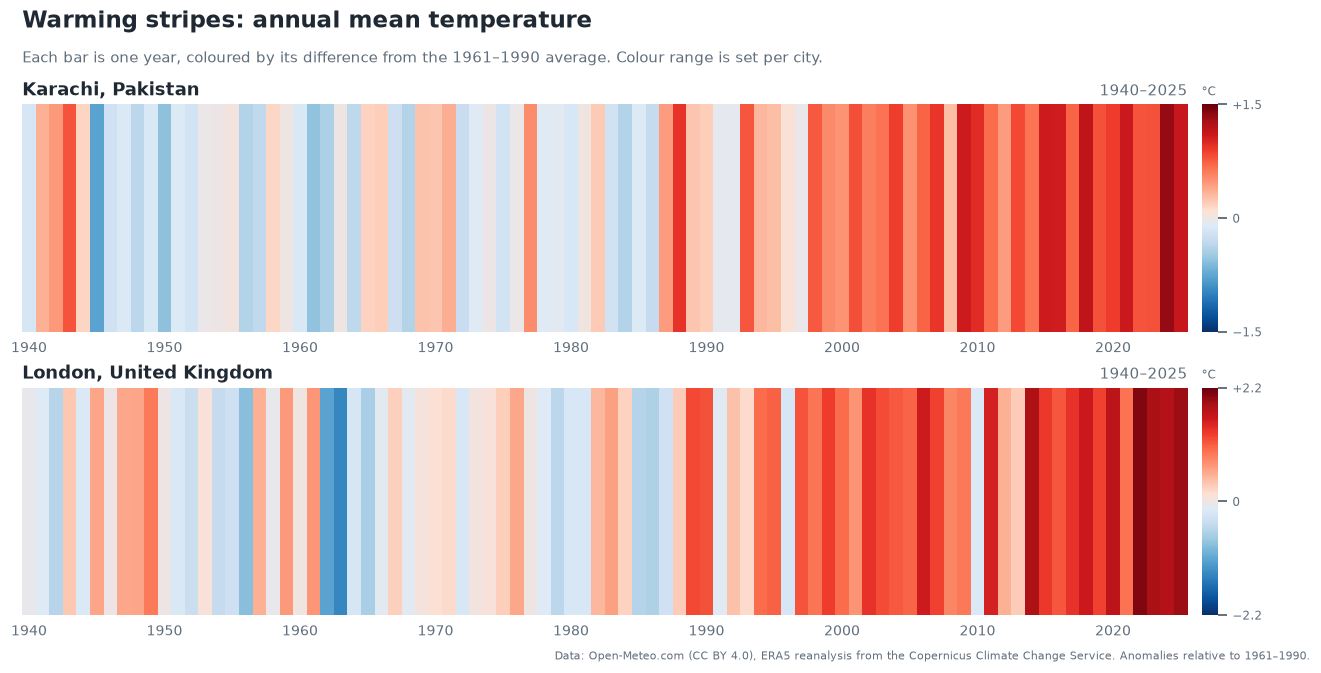

In [5]:
fig = plots.plot_warming_stripes(results, config)
plt.show()

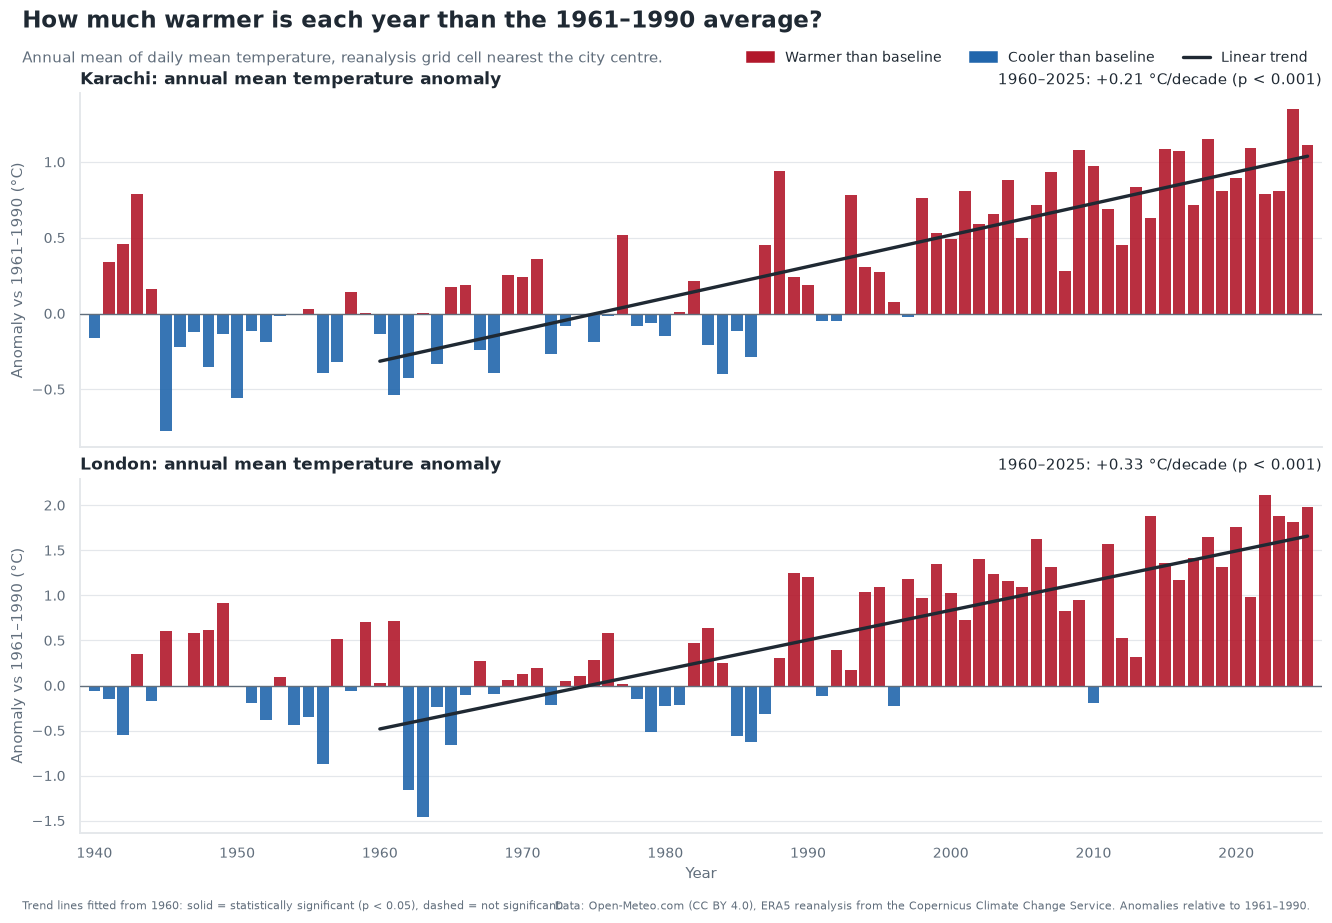

In [6]:
fig = plots.plot_anomaly_trends(results, config)
plt.show()

In [7]:
show(report.trend_table_markdown(results, ["tmean"], trend_start))

| City | Metric | Trend per decade | 95% CI | p (regression) | Mann-Kendall | Sen's slope per decade | p (autocorr.-adjusted) |
|---|---|---|---|---|---|---|---|
| Karachi | Annual mean temperature | +0.21 °C | [+0.17, +0.24] | < 0.001 | increasing | +0.21 °C | < 0.001 |
| London | Annual mean temperature | +0.33 °C | [+0.26, +0.40] | < 0.001 | increasing | +0.33 °C | < 0.001 |

**Conclusion.** Both cities have warmed, and the trend is highly significant in both. London is warming at +0.33 °C per decade (95% CI +0.26 to +0.40) and Karachi at +0.21 °C per decade (95% CI +0.17 to +0.24). The Sen's slopes are almost identical to the regression slopes, so no single extreme year is driving the result. The residual lag-1 autocorrelation is small (0.10 for Karachi and 0.15 for London) and the autocorrelation-adjusted p-values remain below 0.001, so the conclusion survives that limitation. In 2016-2025 the average year was 1.0 °C (Karachi) and 1.6 °C (London) warmer than the 1961-1990 baseline.

## Q2. Are nights warming faster than days?

**Method.** Daily maximum (Tmax, a daytime value) and daily minimum (Tmin, a night-time value) are averaged by year and trended separately. The **diurnal temperature range** (Tmax minus Tmin) shrinks if nights warm faster, so its trend directly tests whether the two rates differ.

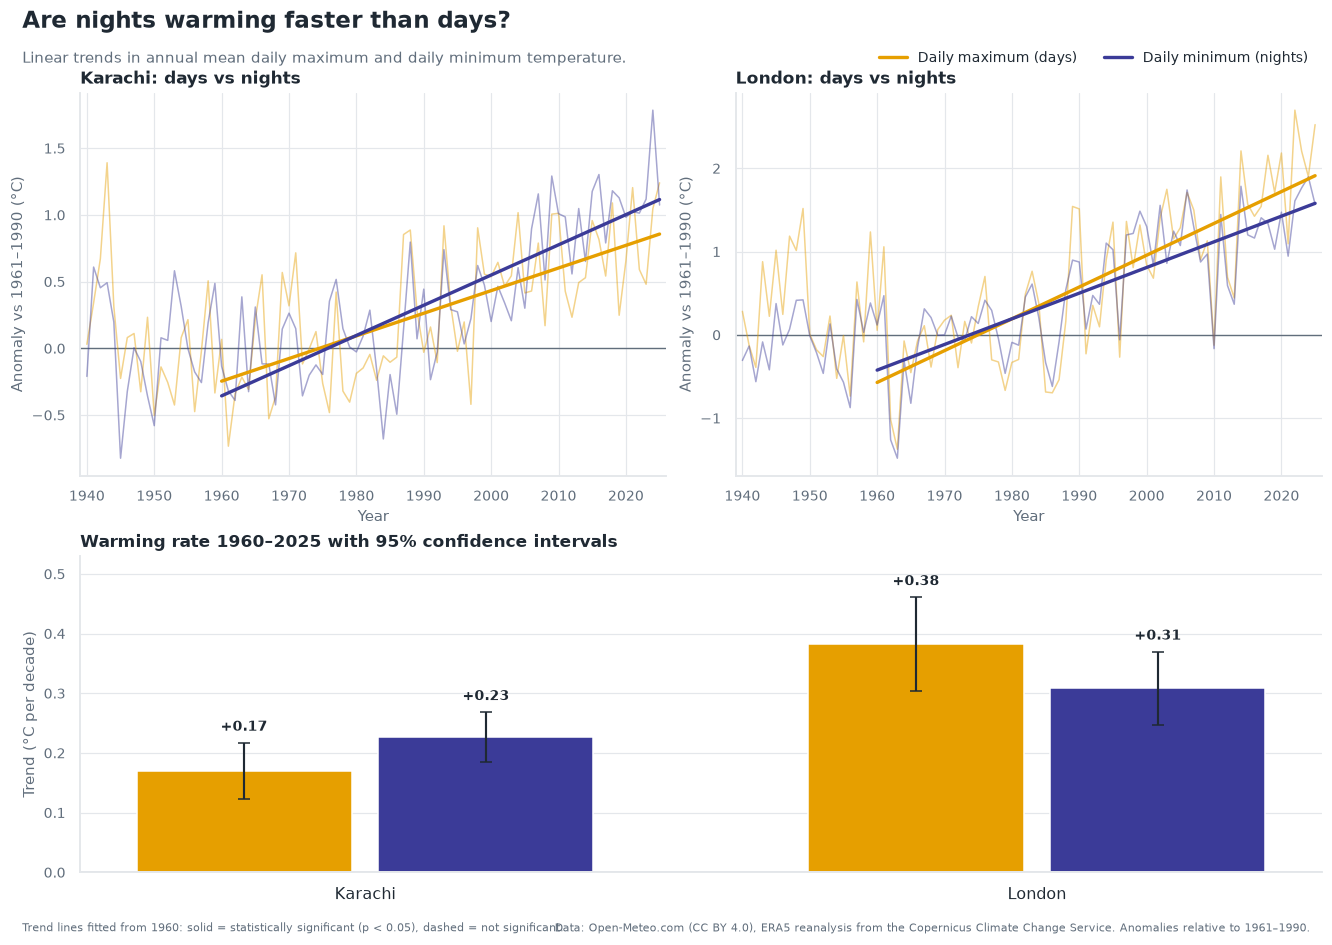

In [8]:
fig = plots.plot_tmax_vs_tmin(results, config)
plt.show()

In [9]:
show(report.trend_table_markdown(results, ["tmax", "tmin", "dtr"], trend_start))

| City | Metric | Trend per decade | 95% CI | p (regression) | Mann-Kendall | Sen's slope per decade | p (autocorr.-adjusted) |
|---|---|---|---|---|---|---|---|
| Karachi | Annual mean of daily maximum | +0.17 °C | [+0.12, +0.22] | < 0.001 | increasing | +0.18 °C | < 0.001 |
| London | Annual mean of daily maximum | +0.38 °C | [+0.30, +0.46] | < 0.001 | increasing | +0.39 °C | < 0.001 |
| Karachi | Annual mean of daily minimum | +0.23 °C | [+0.18, +0.27] | < 0.001 | increasing | +0.23 °C | < 0.001 |
| London | Annual mean of daily minimum | +0.31 °C | [+0.25, +0.37] | < 0.001 | increasing | +0.30 °C | < 0.001 |
| Karachi | Diurnal range (Tmax minus Tmin) | −0.06 °C | [−0.10, −0.01] | 0.018 | decreasing | −0.06 °C | 0.022 |
| London | Diurnal range (Tmax minus Tmin) | +0.07 °C | [+0.03, +0.12] | 0.002 | increasing | +0.07 °C | 0.011 |

**Conclusion.** The two cities behave differently.

- **Karachi: nights warm faster.** Tmin rises +0.23 °C per decade against +0.17 for Tmax, so the daily range is narrowing by 0.06 °C per decade (p = 0.018). The effect is modest: the confidence intervals of the two trends overlap. Common explanations are humidity and cloud, which trap heat at night, and city growth. This analysis cannot tell which applies, and the reanalysis grid cell does not resolve city-scale heat-island effects.
- **London: days warm slightly faster.** Tmax rises +0.38 against +0.31 °C per decade for Tmin, so the range widens by 0.07 °C per decade (p = 0.002). The nights-warm-faster pattern often reported globally does not appear in London's data here.

Both diurnal-range trends are small compared with the warming itself, so the safe conclusion is that days and nights both warmed strongly, with a modest and city-specific difference between them.

## Q3. How has extreme heat changed?

**Method.** Two definitions of an "extreme hot day" are counted per year (see [Data & methods](#Statistical-methods)): days above a **fixed threshold** (40 °C in Karachi, 30 °C in London) and days above the **1961-1990 95th percentile** of daily maximum (36.7 °C in Karachi, 22.8 °C in London). The dotted line on the right-hand charts is the value each city would average if the climate had stayed at its baseline: about 18 days.

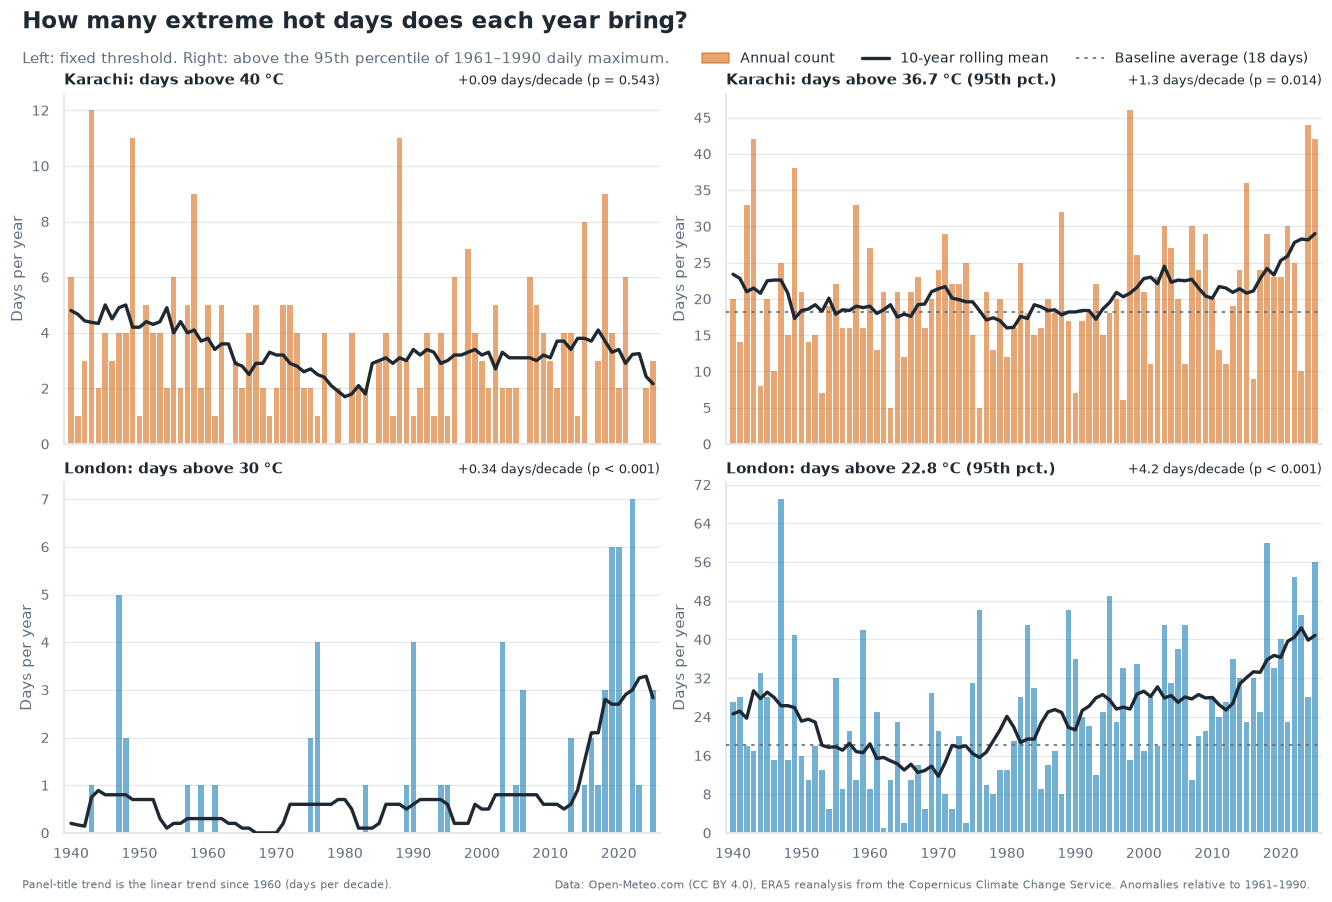

In [10]:
fig = plots.plot_extreme_heat(results, config)
plt.show()

In [11]:
show(report.period_means_markdown(results, ["hot_days_fixed", "hot_days_pct"], [baseline, recent_normal, (2016, 2025)]))
show(report.trend_table_markdown(results, ["hot_days_fixed", "hot_days_pct"], trend_start))

| City | Metric | 1961–1990 | 1991–2020 | 2016–2025 |
|---|---|---|---|---|
| Karachi | Days above fixed heat threshold (days/year) | 2.7 | 3.3 | 2.9 |
| London | Days above fixed heat threshold (days/year) | 0.4 | 1.0 | 2.9 |
| Karachi | Days above baseline 95th percentile (days/year) | 18.1 | 21.5 | 25.9 |
| London | Days above baseline 95th percentile (days/year) | 18.3 | 29.0 | 39.6 |

| City | Metric | Trend per decade | 95% CI | p (regression) | Mann-Kendall | Sen's slope per decade | p (autocorr.-adjusted) |
|---|---|---|---|---|---|---|---|
| Karachi | Days above fixed heat threshold | +0.1 days | [−0.2, +0.4] | 0.543 | no trend | +0.0 days | 0.786 |
| London | Days above fixed heat threshold | +0.3 days | [+0.1, +0.5] | < 0.001 | increasing | +0.0 days | 0.007 |
| Karachi | Days above baseline 95th percentile | +1.3 days | [+0.3, +2.4] | 0.014 | increasing | +1.2 days | 0.010 |
| London | Days above baseline 95th percentile | +4.2 days | [+2.7, +5.7] | < 0.001 | increasing | +4.3 days | < 0.001 |

**Conclusion.**

- **London: clear and accelerating.** Days above the 95th percentile went from 18 a year in the baseline to 40 in 2016-2025, and 56 in 2025 alone. The trend is +4.2 days per decade (p < 0.001). Days of 30 °C or more, rare before the 1990s, averaged 2.9 a year in 2016-2025.
- **Karachi: a real but smaller increase.** Days above its own 95th percentile (36.7 °C) rose from 18 to 26 a year (+1.3 days per decade, p = 0.014). Days above the fixed 40 °C show no significant trend (p = 0.543). A likely reason is that a high fixed threshold is crossed only in rare extreme spells, while the shift shows up in ordinary hot days, but this analysis does not test that.
- **Why the percentile method matters.** A fixed number measures the climate against one arbitrary value, so the answer depends on the value chosen. The percentile method measures each city against *its own* normal, so both cities start at about 18 days a year and the increases (+1.3 versus +4.2 days per decade) can be compared directly.

## Q4. Has rainfall changed?

**Method.** Three measures per year: total rainfall, the heaviest single day, and the longest dry spell (consecutive days under 1 mm). Rainfall is far more variable than temperature, so trend tests need more years to detect a change of a given size.

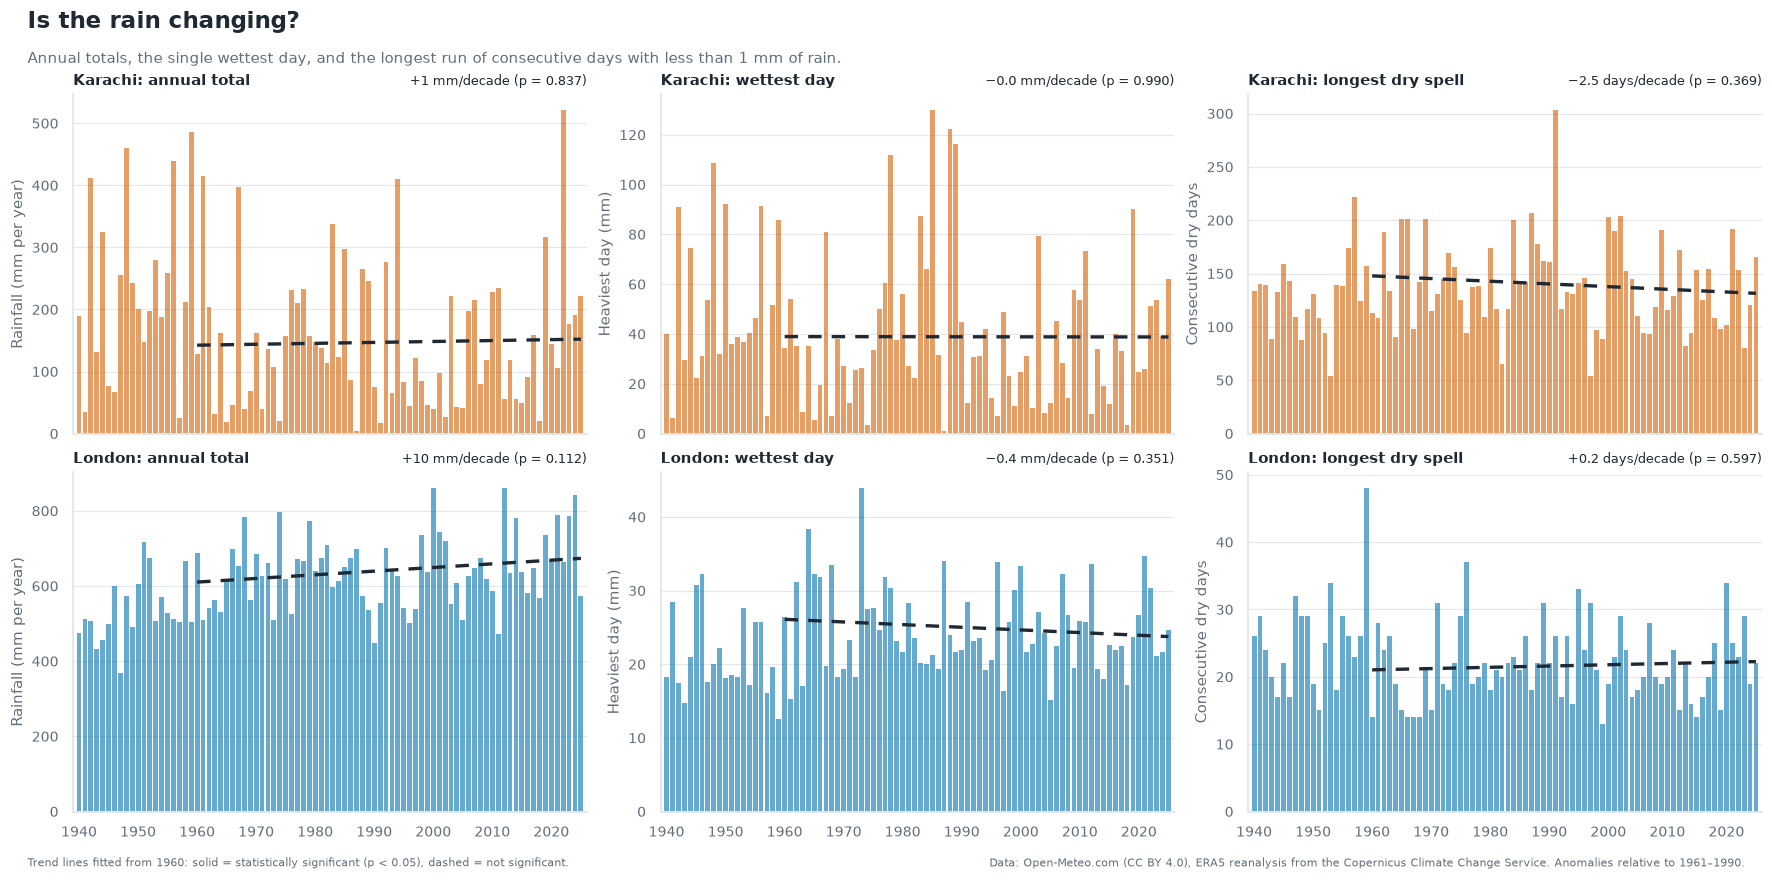

In [12]:
fig = plots.plot_rainfall_trends(results, config)
plt.show()

In [13]:
show(report.trend_table_markdown(results, ["precip_total", "rx1day", "longest_dry_spell"], trend_start))
show(report.period_means_markdown(results, ["precip_total", "rx1day", "longest_dry_spell"], [baseline, recent_normal]))

| City | Metric | Trend per decade | 95% CI | p (regression) | Mann-Kendall | Sen's slope per decade | p (autocorr.-adjusted) |
|---|---|---|---|---|---|---|---|
| Karachi | Annual rainfall | +1.5 mm | [−13.0, +16.0] | 0.837 | no trend | +2.0 mm | 0.816 |
| London | Annual rainfall | +9.7 mm | [−2.3, +21.7] | 0.112 | no trend | +9.1 mm | 0.193 |
| Karachi | Heaviest rain day of the year | −0.0 mm | [−3.9, +3.9] | 0.990 | no trend | +0.6 mm | 0.714 |
| London | Heaviest rain day of the year | −0.4 mm | [−1.1, +0.4] | 0.351 | no trend | −0.2 mm | 0.571 |
| Karachi | Longest dry spell | −2.5 days | [−8.1, +3.0] | 0.369 | no trend | −2.3 days | 0.292 |
| London | Longest dry spell | +0.2 days | [−0.5, +0.9] | 0.597 | no trend | +0.2 days | 0.457 |

| City | Metric | 1961–1990 | 1991–2020 |
|---|---|---|---|
| Karachi | Annual rainfall (mm/year) | 155.6 | 123.6 |
| London | Annual rainfall (mm/year) | 626.9 | 640.8 |
| Karachi | Heaviest rain day of the year (mm/year) | 45.9 | 30.8 |
| London | Heaviest rain day of the year (mm/year) | 25.4 | 24.1 |
| Karachi | Longest dry spell (days/year) | 145.0 | 134.8 |
| London | Longest dry spell (days/year) | 21.7 | 21.5 |

**Conclusion.** None of the three rainfall measures shows a statistically significant trend in either city since 1960. The Mann-Kendall test agrees.

- **Karachi** is extremely variable: annual totals range from 4 mm (1987) to 521 mm (2022), and the wettest single day in the record delivered 130 mm (1985). With swings that large, a real trend of a few mm per decade would be invisible.
- **London** shows a positive slope in annual rainfall (+9.7 mm per decade), but it is not significant (p = 0.112). The confidence interval includes zero, so "wetter" would overstate the evidence.

"No significant trend" is not the same as "no change". It means this record cannot distinguish a change from natural variability. Reanalysis rainfall is also model-derived and less reliable than reanalysis temperature.

## Q5. How do the seasons differ between climate normals?

**Method.** Monthly mean temperature and monthly rainfall totals are averaged over the standard **1961-1990** and **1991-2020** normals and compared month by month. The shaded area shows how much warmer each month has become.

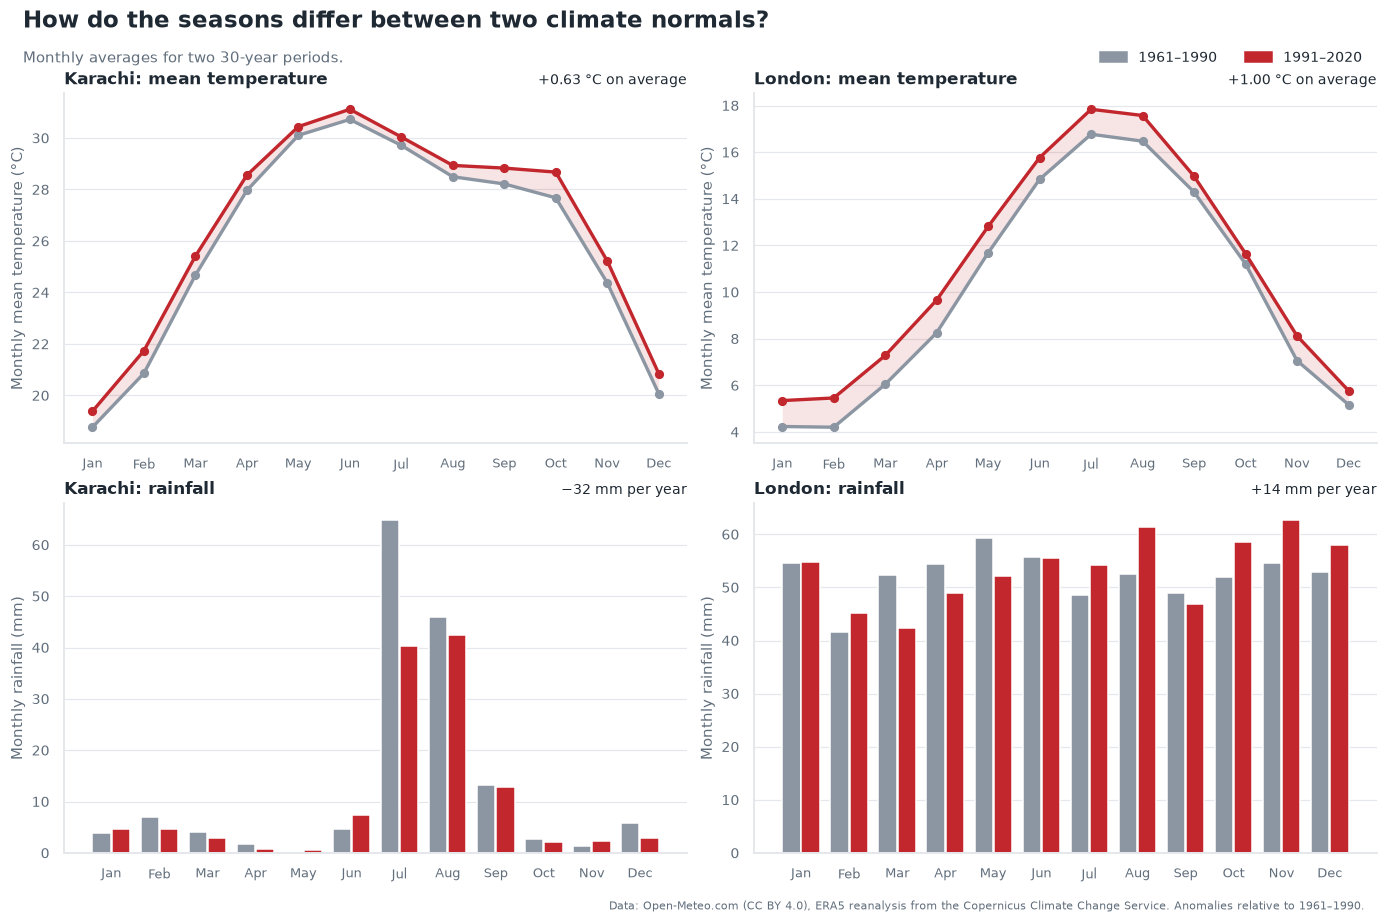

In [14]:
fig = plots.plot_monthly_normals(results, config)
plt.show()

In [15]:
show(report.normals_markdown(results))

| Month | Karachi temp. change (°C) | Karachi rain change (mm) | London temp. change (°C) | London rain change (mm) |
|---|---|---|---|---|
| Jan | +0.62 | +0.7 | +1.11 | +0.3 |
| Feb | +0.88 | −2.4 | +1.25 | +3.7 |
| Mar | +0.74 | −1.1 | +1.24 | −10.1 |
| Apr | +0.59 | −1.0 | +1.40 | −5.4 |
| May | +0.34 | +0.3 | +1.13 | −7.2 |
| Jun | +0.39 | +2.7 | +0.93 | −0.0 |
| Jul | +0.33 | −24.6 | +1.07 | +5.7 |
| Aug | +0.44 | −3.6 | +1.10 | +9.0 |
| Sep | +0.62 | −0.4 | +0.68 | −1.9 |
| Oct | +1.00 | −0.5 | +0.44 | +6.5 |
| Nov | +0.85 | +0.9 | +1.06 | +8.2 |
| Dec | +0.78 | −2.9 | +0.60 | +5.1 |
| **Year** | **+0.63** (mean) | **−32.0** (total) | **+1.00** (mean) | **+13.8** (total) |

The heatmap shows the same information year by year: each cell is one month of one year, coloured by how far it departs from that month's 1961-1990 average. Both cities share a colour scale, so London's larger swings and stronger recent warming are visible directly.

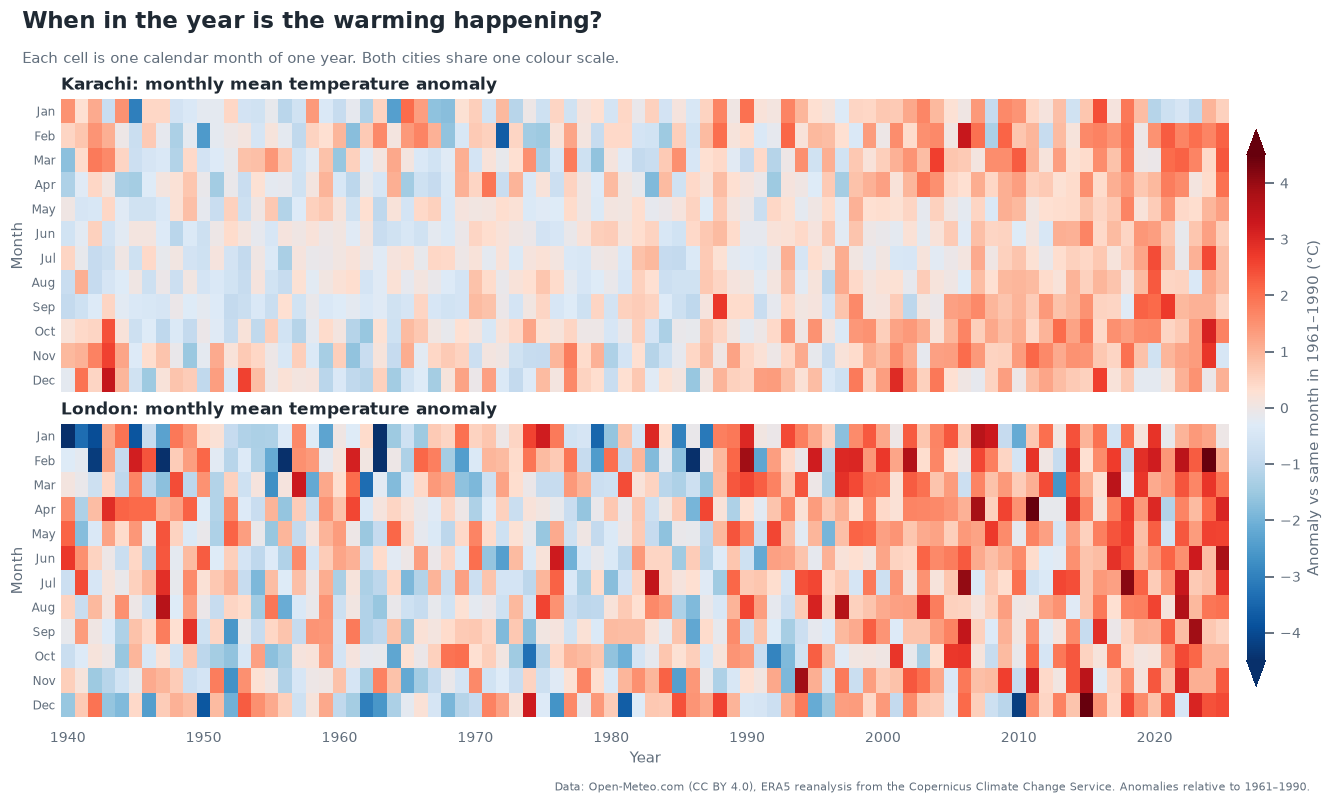

In [16]:
fig = plots.plot_monthly_heatmaps(results, config)
plt.show()

**Conclusion.**

- **Temperature:** Every month is warmer in the 1991-2020 normal than in 1961-1990 in both cities. London warmed most in Apr (+1.4 °C) and least in Oct (+0.4 °C). Karachi warmed most in Oct (+1.0 °C) and least in Jul (+0.3 °C). Averaged over the year, London warmed by 1.00 °C and Karachi by 0.63 °C between the two normals.
- **Rainfall:** Karachi's yearly total is 32 mm lower in the newer normal, and most of that is the July monsoon peak (−25 mm). London's total is +14 mm, with a drier spring (March −10 mm) and wetter late summer and autumn. These are differences between two 30-year averages of a very variable quantity, and no significance test is attached to them, so treat them as descriptive.

## Q6. Which city is warming faster?

**Method.** Both trends are computed on the same 1960-2025 window. The difference between two slopes is tested with a z-test that combines their standard errors: {difference} divided by the square root of the sum of the squared standard errors.

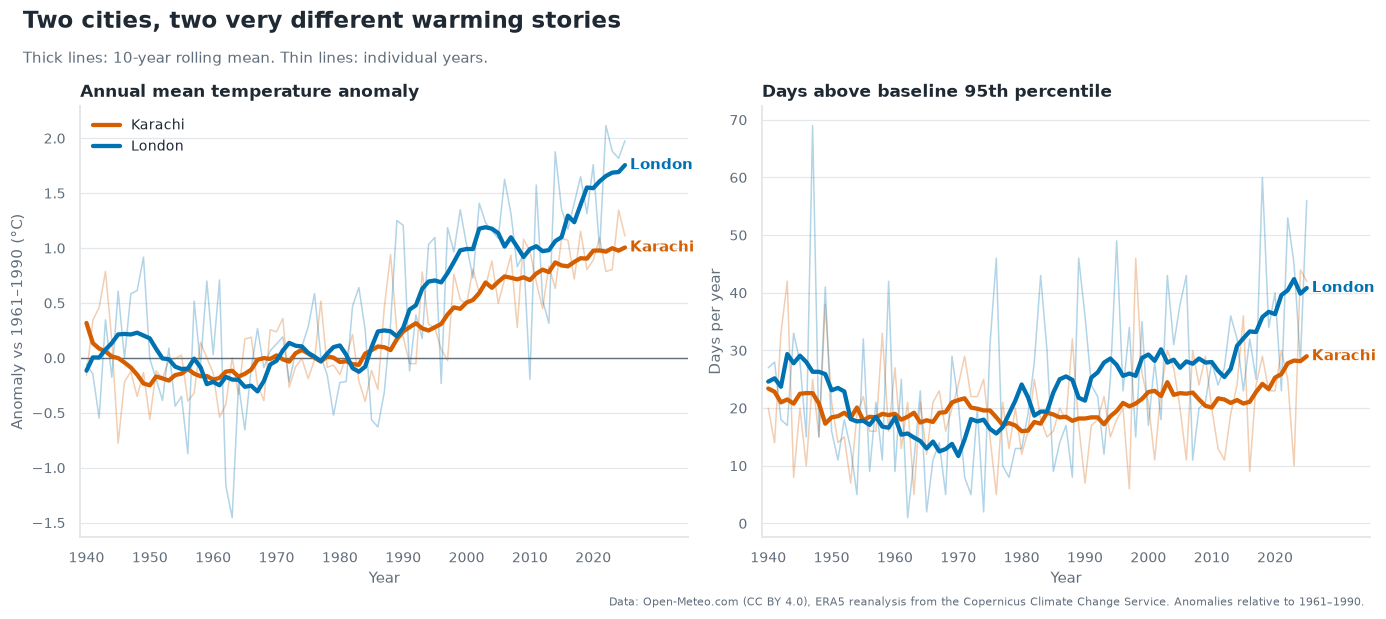

In [17]:
fig = plots.plot_city_comparison(results, config)
plt.show()

In [18]:
show(report.comparison_markdown(results, ["tmean", "tmax", "tmin", "hot_days_pct"], trend_start))

| Metric | Karachi trend | London trend | Difference (Karachi minus London) | p (difference) |
|---|---|---|---|---|
| Annual mean temperature (°C/decade) | +0.21 | +0.33 | −0.12 | 0.001 |
| Annual mean of daily maximum (°C/decade) | +0.17 | +0.38 | −0.21 | < 0.001 |
| Annual mean of daily minimum (°C/decade) | +0.23 | +0.31 | −0.08 | 0.028 |
| Days above baseline 95th percentile (days/decade) | +1.3 | +4.2 | −2.9 | 0.002 |

**Conclusion.** **London is warming faster**, and the difference is statistically significant for annual mean temperature (+0.12 °C per decade faster, p = 0.001), for daytime highs and for the number of days above each city's own baseline 95th percentile. The gap is widest for daytime maximum temperature (0.21 °C per decade), and smallest for nights (0.08 °C per decade). Karachi still warmed significantly, at about 63% of London's rate.

On extremes, the two cities have very different profiles. London's hot days rise steadily and sharply, and its hottest recent years dominate the record. Karachi's extreme days rise more gently, and its fixed 40 °C days do not trend at all. Higher-latitude, maritime London is warming more than subtropical, coastal Karachi in this dataset. That fits the general pattern that high-latitude land warms faster than low-latitude coasts, though this analysis does not test that explanation.

## Robustness check

The results above use 1960 as the trend start. The table shows the temperature trends from three start years. 1940 is the whole record, 1960 is the main analysis, and 1979 begins the satellite era, when ERA5 is best constrained by observations.

In [19]:
show(report.sensitivity_markdown(results, ["tmean", "tmax", "tmin"], [1940, 1960, 1979]))

| City | Metric | from 1940 | from 1960 | from 1979 |
|---|---|---|---|---|
| Karachi | Annual mean temperature (°C/decade) | +0.15 (p <0.001) | +0.21 (p <0.001) | +0.26 (p <0.001) |
| London | Annual mean temperature (°C/decade) | +0.21 (p <0.001) | +0.33 (p <0.001) | +0.40 (p <0.001) |
| Karachi | Annual mean of daily maximum (°C/decade) | +0.10 (p <0.001) | +0.17 (p <0.001) | +0.21 (p <0.001) |
| London | Annual mean of daily maximum (°C/decade) | +0.22 (p <0.001) | +0.38 (p <0.001) | +0.50 (p <0.001) |
| Karachi | Annual mean of daily minimum (°C/decade) | +0.15 (p <0.001) | +0.23 (p <0.001) | +0.32 (p <0.001) |
| London | Annual mean of daily minimum (°C/decade) | +0.22 (p <0.001) | +0.31 (p <0.001) | +0.34 (p <0.001) |

Warming is significant and positive from every start year, so the main conclusion does not depend on the chosen window. The trend rate is higher for later start years, as expected when warming accelerates. Very early ERA5 years (before about 1950) rest on far fewer observations, which is one reason the main analysis starts in 1960.

## Limitations

- **Reanalysis is not a thermometer.** ERA5 is a model corrected by observations, on a grid of about 25 km. Each result describes a grid cell near the city, not the city centre. Urban heat islands, which make city centres several degrees warmer than surroundings at night, are not resolved. Karachi's grid cell sits about 15 km north of the city centre, and London's about 9 km to the west.
- **Changing observations.** The number and type of observations assimilated by ERA5 changed over time (far fewer before the 1950s, satellites from 1979). Trends that start early can partly reflect that. The start-year sensitivity check above is one guard against it, and a sudden model switch (found and removed here) is an extreme example of the same issue.
- **Autocorrelation.** Consecutive years are related, which inflates the significance of trend tests. The residual autocorrelation here is small, and an autocorrelation-adjusted test agrees, but the p-values remain approximate. The rainfall series, with many low-count events, are the least well described by standard tests.
- **Many tests.** About twenty trend tests are run per city. At the 5% level one or two would appear significant by chance alone, so isolated borderline results should not be over-interpreted. The main temperature results are far beyond that.
- **Counts and thresholds.** Extreme-day counts depend on the thresholds chosen, and many years have zero events, which makes Sen's slope 0. The percentile threshold here is one value for the whole year, so most "extreme" days fall in summer. A calendar-day percentile (as in the international ETCCDI indices) would spread them across the year.
- **Rainfall.** Reanalysis precipitation is model-derived, and in an arid, monsoon-driven place like Karachi it is especially uncertain.
- **Two cities do not make a global claim.** The results describe these two places only.
- **Correlation and cause.** This analysis measures *how much* the climate has changed. It does not attribute the change to a cause. Attribution studies with climate models, such as those summarised by the IPCC, address that question, and this project does not.

## Reproducing this notebook

```bash
pip install -r requirements.txt
python run_all.py
jupyter lab notebooks/climate_analysis.ipynb
```

The processed data is committed, so the notebook also runs without downloading anything. `python -m pytest` runs the unit tests for the analysis functions.

*Weather data by Open-Meteo.com (CC BY 4.0), based on ERA5 reanalysis from the Copernicus Climate Change Service.*